# Dự đoán lỗi phần mềm sử dụng Học máy có giám sát và Kỹ thuật kết hợp

**Dự đoán lỗi phần mềm sử dụng Học máy có giám sát và Kỹ thuật kết hợp: Một nghiên cứu so sánh**.

## 1.


In [ ]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import arff

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

RANDOM_STATE = 20
N_SPLITS = 10
N_ESTIMATORS = 50
N_JOBS = -1

## 2. Các chỉ số phần mềm

- LOC metrics: số dòng code, số dòng comment, số dòng thực thi...
- McCabe metrics: cyclomatic complexity, design complexity, essential complexity...
- Halstead metrics: effort, difficulty, volume, length...

In [ ]:
from pathlib import Path

DATA_DIR = Path("data") / "D'"

DATASET_FILES = {
    'CM1': DATA_DIR / 'CM1.arff',
    'JM1': DATA_DIR / 'JM1.arff',
    'KC1': DATA_DIR / 'KC1.arff',
    'PC4': DATA_DIR / 'PC4.arff',
    'MC1': DATA_DIR / 'MC1.arff',
    'MC2': DATA_DIR / 'MC2.arff',
    'MW1': DATA_DIR / 'MW1.arff',
    'PC1': DATA_DIR / 'PC1.arff',
    'PC2': DATA_DIR / 'PC2.arff',
    'PC3': DATA_DIR / 'PC3.arff',
}

for name, path in DATASET_FILES.items():
    print(f'{name:>4}: {path} | exists = {path.exists()}')

Current working directory: /Users/tuna/Hoc/KPDL/Lab10
 CM1: data/D'/CM1.arff | exists = True
 JM1: data/D'/JM1.arff | exists = True
 KC1: data/D'/KC1.arff | exists = True
 PC4: data/D'/PC4.arff | exists = True
 MC1: data/D'/MC1.arff | exists = True
 MC2: data/D'/MC2.arff | exists = True
 MW1: data/D'/MW1.arff | exists = True
 PC1: data/D'/PC1.arff | exists = True
 PC2: data/D'/PC2.arff | exists = True
 PC3: data/D'/PC3.arff | exists = True


In [ ]:
def decode_if_bytes(x):
    if isinstance(x, bytes):
        return x.decode('utf-8', errors='ignore')
    return x


def detect_target_column(df: pd.DataFrame) -> str:
    candidates = ['Defective', 'defective', 'label', 'Label', 'bug', 'Bug', 'class', 'Class']
    for col in candidates:
        if col in df.columns:
            return col
    return df.columns[-1]


def convert_target_to_binary(y: pd.Series) -> pd.Series:
    y = y.map(decode_if_bytes)

    numeric_y = pd.to_numeric(y, errors='coerce')
    if numeric_y.notna().mean() > 0.8:
        return (numeric_y.fillna(0) > 0).astype(int)

    y_str = y.astype(str).str.strip().str.lower()
    positive_values = {'y', 'yes', 'true', 't', '1', 'defective', 'buggy', 'faulty'}
    negative_values = {'n', 'no', 'false', 'f', '0', 'clean', 'non-defective', 'not_defective'}

    mapped = []
    for value in y_str:
        if value in positive_values:
            mapped.append(1)
        elif value in negative_values:
            mapped.append(0)
        else:
            try:
                mapped.append(1 if float(value) > 0 else 0)
            except Exception:
                raise ValueError(f'Không nhận diện được nhãn: {value}')
    return pd.Series(mapped, index=y.index, dtype=int)


def load_arff_dataset(path: Path) -> tuple[pd.DataFrame, pd.Series, str]:
    data, meta = arff.loadarff(path)
    df = pd.DataFrame(data)

    if df.empty:
        target_col = detect_target_column(df) if len(df.columns) > 0 else 'unknown'
        return pd.DataFrame(), pd.Series(dtype=int), target_col

    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].map(decode_if_bytes)

    target_col = detect_target_column(df)
    y = convert_target_to_binary(df[target_col])
    X = df.drop(columns=[target_col])

    numeric_cols = []
    categorical_cols = []
    for col in X.columns:
        converted = pd.to_numeric(X[col], errors='coerce')
        if converted.notna().mean() >= 0.9:
            X[col] = converted
            numeric_cols.append(col)
        else:
            categorical_cols.append(col)

    if categorical_cols:
        X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.apply(pd.to_numeric, errors='coerce')
    X = X.fillna(X.median(numeric_only=True))
    X = X.fillna(0)

    return X, y, target_col

In [ ]:
datasets = {}
summary_rows = []
skipped_datasets = []

for name, path in DATASET_FILES.items():
    try:
        X, y, target_col = load_arff_dataset(path)
        if len(X) == 0 or len(y) == 0:
            skipped_datasets.append((name, 'File không có dữ liệu hoặc rỗng'))
            continue
        if y.nunique() < 2:
            skipped_datasets.append((name, 'Dataset chỉ có 1 lớp nhãn'))
            continue

        datasets[name] = {'X': X, 'y': y, 'target_col': target_col}
        summary_rows.append({
            'Dataset': name,
            'Modules': len(y),
            'Defective Modules': int(y.sum()),
            'Non-defective Modules': int((y == 0).sum()),
            'Defect Ratio': float(y.mean()),
            'Attributes': X.shape[1],
            'Target Column': target_col,
        })
    except Exception as e:
        skipped_datasets.append((name, str(e)))

summary_df = pd.DataFrame(summary_rows).sort_values('Dataset').reset_index(drop=True)
summary_df

,Dataset,Modules,Defective Modules,Non-defective Modules,Defect Ratio,Attributes,Target Column
0,CM1,344,42,302,0.122093,37,Defective
1,JM1,9591,1759,7832,0.183401,21,label
2,KC1,2095,325,1770,0.155131,21,Defective
3,MC1,8737,68,8669,0.007783,38,Defective
4,MC2,125,44,81,0.352000,39,Defective
5,MW1,263,27,236,0.102662,37,Defective
6,PC1,735,61,674,0.082993,37,Defective
7,PC2,1493,16,1477,0.010717,36,Defective
8,PC3,1099,138,961,0.125569,37,Defective
9,PC4,1379,178,1201,0.129079,37,Defective


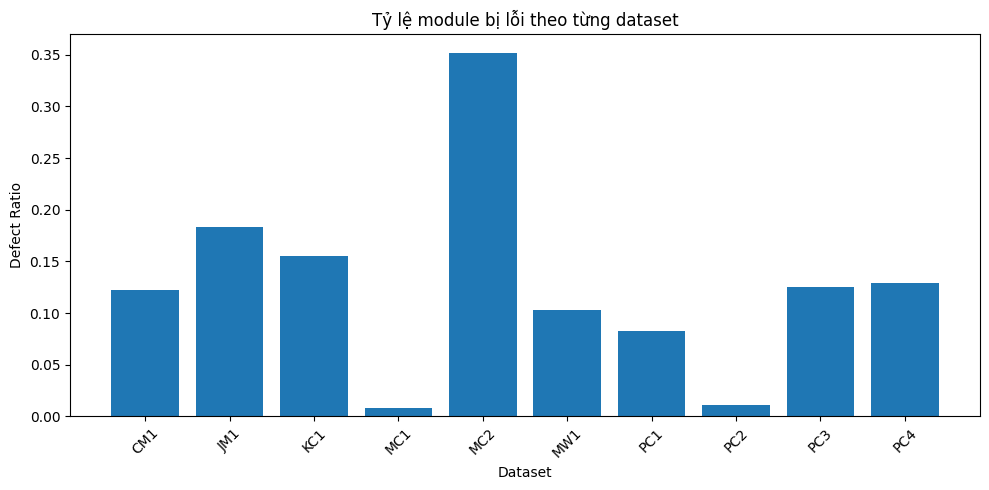

In [ ]:
if not summary_df.empty:
    plt.figure(figsize=(10, 5))
    plt.bar(summary_df['Dataset'], summary_df['Defect Ratio'])
    plt.title('Tỷ lệ module bị lỗi theo từng dataset')
    plt.xlabel('Dataset')
    plt.ylabel('Defect Ratio')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 3. Các thước đo đánh giá

Các chỉ số đánh giá chính gồm:

- Accuracy
- Precision
- Recall
- F-score/F1-score
- ROC-AUC

In [ ]:
def get_positive_scores(model, X_test):
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_test)
        if proba.ndim == 2 and proba.shape[1] >= 2:
            return proba[:, 1]
    if hasattr(model, 'decision_function'):
        scores = model.decision_function(X_test)
        if np.ndim(scores) == 1:
            return scores
        return scores[:, 1]
    return None


def safe_roc_auc(y_true, y_score):
    try:
        if y_score is None or len(np.unique(y_true)) < 2:
            return np.nan
        return roc_auc_score(y_true, y_score)
    except Exception:
        return np.nan

## 4. Phương pháp thực nghiệm

In [ ]:
def build_models(random_state=RANDOM_STATE, n_estimators=N_ESTIMATORS, n_jobs=N_JOBS):
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=random_state,
        n_jobs=n_jobs,
        class_weight=None,
    )

    ds = DecisionTreeClassifier(
        random_state=random_state,
    )

    svm = LinearSVC(
        random_state=random_state,
        max_iter=10000,
        dual='auto',
    )

    lr = LogisticRegression(
        random_state=random_state,
        max_iter=10000,
        solver='liblinear',
    )

    models = {
        'RF': rf,
        'DS': ds,
        'SVM': svm,
        'LR': lr,

        # AdaBoost với từng base learner
        'AdaBoost-RF': AdaBoostClassifier(
            estimator=clone(rf),
            n_estimators=n_estimators,
            random_state=random_state,
        ),
        'AdaBoost-DS': AdaBoostClassifier(
            estimator=clone(ds),
            n_estimators=n_estimators,
            random_state=random_state,
        ),
        'AdaBoost-SVM': AdaBoostClassifier(
            estimator=clone(svm),
            n_estimators=n_estimators,
            random_state=random_state,
        ),
        'AdaBoost-LR': AdaBoostClassifier(
            estimator=clone(lr),
            n_estimators=n_estimators,
            random_state=random_state,
        ),

        # Bagging với từng base learner
        'Bagging-RF': BaggingClassifier(
            estimator=clone(rf),
            n_estimators=10,
            random_state=random_state,
            n_jobs=n_jobs,
        ),
        'Bagging-DS': BaggingClassifier(
            estimator=clone(ds),
            n_estimators=n_estimators,
            random_state=random_state,
            n_jobs=n_jobs,
        ),
        'Bagging-SVM': BaggingClassifier(
            estimator=clone(svm),
            n_estimators=10,
            random_state=random_state,
            n_jobs=n_jobs,
        ),
        'Bagging-LR': BaggingClassifier(
            estimator=clone(lr),
            n_estimators=n_estimators,
            random_state=random_state,
            n_jobs=n_jobs,
        ),
    }

    return models

models = build_models()
list(models.keys())

['RF',
 'DS',
 'SVM',
 'LR',
 'AdaBoost-RF',
 'AdaBoost-DS',
 'AdaBoost-SVM',
 'AdaBoost-LR',
 'Bagging-RF',
 'Bagging-DS',
 'Bagging-SVM',
 'Bagging-LR']

In [ ]:
def evaluate_model_on_dataset(
    X: pd.DataFrame,
    y: pd.Series,
    model,
    dataset_name: str,
    model_name: str,
    n_splits: int = N_SPLITS,
    random_state: int = RANDOM_STATE,
):

    y = pd.Series(y).astype(int).reset_index(drop=True)
    X = X.reset_index(drop=True)

    class_counts = y.value_counts()
    min_class_count = int(class_counts.min())

    if len(class_counts) < 2:
        raise ValueError(f'{dataset_name} chỉ có một lớp, không thể phân loại nhị phân.')

    actual_splits = min(n_splits, min_class_count)
    if actual_splits < 2:
        raise ValueError(f'{dataset_name} có quá ít mẫu ở lớp thiểu số.')

    skf = StratifiedKFold(
        n_splits=actual_splits,
        shuffle=True,
        random_state=random_state,
    )

    fold_rows = []
    y_true_all = []
    y_pred_all = []
    y_score_all = []

    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
        y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        train_class_counts = y_train.value_counts()
        train_min_class = int(train_class_counts.min())
        if train_min_class >= 2:
            k_neighbors = min(5, train_min_class - 1)
            smote = SMOTE(random_state=random_state, k_neighbors=k_neighbors)
            X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
        else:
            X_train_resampled, y_train_resampled = X_train_scaled, y_train

        fitted_model = clone(model)
        fitted_model.fit(X_train_resampled, y_train_resampled)

        y_pred = fitted_model.predict(X_test_scaled)
        y_score = get_positive_scores(fitted_model, X_test_scaled)

        # Metrics
        row = {
            'Dataset': dataset_name,
            'Model': model_name,
            'Fold': fold_idx,
            'N Splits': actual_splits,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision_weighted': precision_score(y_test, y_pred, average='weighted', zero_division=0),
            'Recall_weighted': recall_score(y_test, y_pred, average='weighted', zero_division=0),
            'F1_weighted': f1_score(y_test, y_pred, average='weighted', zero_division=0),
            'ROC_AUC': safe_roc_auc(y_test, y_score),
            'Precision_defective': precision_score(y_test, y_pred, pos_label=1, zero_division=0),
            'Recall_defective': recall_score(y_test, y_pred, pos_label=1, zero_division=0),
            'F1_defective': f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        }
        fold_rows.append(row)

        y_true_all.extend(y_test.tolist())
        y_pred_all.extend(y_pred.tolist())
        if y_score is not None:
            y_score_all.extend(np.asarray(y_score).tolist())

    fold_df = pd.DataFrame(fold_rows)

    avg_row = {
        'Dataset': dataset_name,
        'Model': model_name,
        'N Splits': actual_splits,
        'Accuracy': fold_df['Accuracy'].mean(),
        'Precision_weighted': fold_df['Precision_weighted'].mean(),
        'Recall_weighted': fold_df['Recall_weighted'].mean(),
        'F1_weighted': fold_df['F1_weighted'].mean(),
        'ROC_AUC': fold_df['ROC_AUC'].mean(),
        'Precision_defective': fold_df['Precision_defective'].mean(),
        'Recall_defective': fold_df['Recall_defective'].mean(),
        'F1_defective': fold_df['F1_defective'].mean(),
        'TN': confusion_matrix(y_true_all, y_pred_all, labels=[0, 1])[0, 0],
        'FP': confusion_matrix(y_true_all, y_pred_all, labels=[0, 1])[0, 1],
        'FN': confusion_matrix(y_true_all, y_pred_all, labels=[0, 1])[1, 0],
        'TP': confusion_matrix(y_true_all, y_pred_all, labels=[0, 1])[1, 1],
    }

    return avg_row, fold_df

In [ ]:
all_results = []
all_fold_results = []
errors = []

models = build_models()

for dataset_name, data in datasets.items():
    X = data['X']
    y = data['y']
    print(f'\n===== Dataset: {dataset_name} | samples={len(y)}, features={X.shape[1]}, defective={int(y.sum())} =====')

    for model_name, model in models.items():
        print(f'  Running {model_name}...', end=' ')
        try:
            avg_row, fold_df = evaluate_model_on_dataset(
                X=X,
                y=y,
                model=model,
                dataset_name=dataset_name,
                model_name=model_name,
            )
            all_results.append(avg_row)
            all_fold_results.append(fold_df)
            print('done')
        except Exception as e:
            errors.append({
                'Dataset': dataset_name,
                'Model': model_name,
                'Error': str(e),
            })
            print(f'ERROR: {e}')

results_df = pd.DataFrame(all_results)
fold_results_df = pd.concat(all_fold_results, ignore_index=True) if all_fold_results else pd.DataFrame()
errors_df = pd.DataFrame(errors)

results_df.head()


===== Dataset: CM1 | samples=344, features=37, defective=42 =====
  Running RF... done
  Running DS... done
  Running SVM... done
  Running LR... done
  Running AdaBoost-RF... done
  Running AdaBoost-DS... done
  Running AdaBoost-SVM... done
  Running AdaBoost-LR... done
  Running Bagging-RF... done
  Running Bagging-DS... done
  Running Bagging-SVM... done
  Running Bagging-LR... done

===== Dataset: JM1 | samples=9591, features=21, defective=1759 =====
  Running RF... done
  Running DS... done
  Running SVM... done
  Running LR... done
  Running AdaBoost-RF... done
  Running AdaBoost-DS... done
  Running AdaBoost-SVM... done
  Running AdaBoost-LR... done
  Running Bagging-RF... done
  Running Bagging-DS... done
  Running Bagging-SVM... done
  Running Bagging-LR... done

===== Dataset: KC1 | samples=2095, features=21, defective=325 =====
  Running RF... done
  Running DS... done
  Running SVM... done
  Running LR... done
  Running AdaBoost-RF... done
  Running AdaBoost-DS... done
  R

,Dataset,Model,N Splits,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC,Precision_defective,Recall_defective,F1_defective,TN,FP,FN,TP
0,CM1,RF,10,0.828571,0.808559,0.828571,0.817912,0.733306,0.211667,0.185,0.196587,277,25,34,8
1,CM1,DS,10,0.779160,0.805046,0.779160,0.788288,0.548091,0.165000,0.245,0.194347,257,45,31,11
2,CM1,SVM,10,0.721176,0.849792,0.721176,0.763043,0.736285,0.241627,0.610,0.344028,222,80,16,26
3,CM1,LR,10,0.753109,0.855863,0.753109,0.786691,0.736984,0.273214,0.610,0.373642,233,69,16,26
4,CM1,AdaBoost-RF,10,0.825546,0.809400,0.825546,0.815437,0.546882,0.220238,0.180,0.189444,276,26,34,8


## 5. Kết quả thực nghiệm và thảo luận

In [ ]:
metric_cols = [
    'Dataset', 'Model', 'Accuracy', 'Precision_weighted', 'Recall_weighted',
    'F1_weighted', 'ROC_AUC', 'Precision_defective', 'Recall_defective', 'F1_defective',
    'TN', 'FP', 'FN', 'TP'
]

results_view = results_df[metric_cols].copy()
for col in results_view.select_dtypes(include='number').columns:
    if col not in ['TN', 'FP', 'FN', 'TP']:
        results_view[col] = results_view[col].round(4)

results_view.sort_values(['Dataset', 'F1_weighted'], ascending=[True, False])

,Dataset,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC,Precision_defective,Recall_defective,F1_defective,TN,FP,FN,TP
9,CM1,Bagging-DS,0.8193,0.8333,0.8193,0.8200,0.7871,0.3090,0.3200,0.2810,268,34,28,14
0,CM1,RF,0.8286,0.8086,0.8286,0.8179,0.7333,0.2117,0.1850,0.1966,277,25,34,8
8,CM1,Bagging-RF,0.8141,0.8247,0.8141,0.8170,0.7599,0.2600,0.3000,0.2678,267,35,29,13
4,CM1,AdaBoost-RF,0.8255,0.8094,0.8255,0.8154,0.5469,0.2202,0.1800,0.1894,276,26,34,8
5,CM1,AdaBoost-DS,0.7966,0.8200,0.7966,0.8037,0.5928,0.2152,0.3250,0.2533,260,42,28,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39,PC4,LR,0.8296,0.8980,0.8296,0.8507,0.9068,0.4248,0.8147,0.5558,999,202,33,145
46,PC4,Bagging-SVM,0.8289,0.8965,0.8289,0.8499,0.8624,0.4256,0.8033,0.5527,1000,201,35,143
38,PC4,SVM,0.8238,0.8962,0.8238,0.8460,0.9028,0.4172,0.8092,0.5466,992,209,34,144
43,PC4,AdaBoost-LR,0.8166,0.8827,0.8166,0.8383,0.8875,0.3941,0.7366,0.5109,995,206,47,131


In [ ]:
best_acc = results_df.loc[results_df.groupby('Dataset')['Accuracy'].idxmax()].copy()
best_acc[['Dataset', 'Model', 'Accuracy', 'F1_weighted', 'ROC_AUC', 'Recall_defective']].sort_values('Dataset')

,Dataset,Model,Accuracy,F1_weighted,ROC_AUC,Recall_defective
0,CM1,RF,0.828571,0.817912,0.733306,0.185000
16,JM1,AdaBoost-RF,0.809926,0.801378,0.680515,0.382032
33,KC1,Bagging-DS,0.840579,0.838600,0.821983,0.458428
52,MC1,AdaBoost-RF,0.993018,0.992744,0.820721,0.485714
60,MC2,RF,0.710256,0.693242,0.735486,0.480000
72,MW1,RF,0.866667,0.867272,0.680254,0.416667
88,PC1,AdaBoost-RF,0.918382,0.913805,0.743386,0.409524
100,PC2,AdaBoost-RF,0.983924,0.982593,0.546608,0.100000
117,PC3,Bagging-DS,0.847089,0.848879,0.850758,0.427473
40,PC4,AdaBoost-RF,0.905020,0.907166,0.846904,0.691176


In [ ]:
best_f1 = results_df.loc[results_df.groupby('Dataset')['F1_weighted'].idxmax()].copy()
best_f1[['Dataset', 'Model', 'Accuracy', 'F1_weighted', 'ROC_AUC', 'Recall_defective']].sort_values('Dataset')

,Dataset,Model,Accuracy,F1_weighted,ROC_AUC,Recall_defective
9,CM1,Bagging-DS,0.819328,0.820033,0.787086,0.320000
16,JM1,AdaBoost-RF,0.809926,0.801378,0.680515,0.382032
28,KC1,AdaBoost-RF,0.840118,0.840784,0.723359,0.495644
48,MC1,RF,0.993018,0.992870,0.925255,0.514286
60,MC2,RF,0.710256,0.693242,0.735486,0.480000
72,MW1,RF,0.866667,0.867272,0.680254,0.416667
88,PC1,AdaBoost-RF,0.918382,0.913805,0.743386,0.409524
100,PC2,AdaBoost-RF,0.983924,0.982593,0.546608,0.100000
117,PC3,Bagging-DS,0.847089,0.848879,0.850758,0.427473
40,PC4,AdaBoost-RF,0.905020,0.907166,0.846904,0.691176


In [ ]:

best_auc = results_df.dropna(subset=['ROC_AUC']).loc[
    results_df.dropna(subset=['ROC_AUC']).groupby('Dataset')['ROC_AUC'].idxmax()
].copy()
best_auc[['Dataset', 'Model', 'Accuracy', 'F1_weighted', 'ROC_AUC', 'Recall_defective']].sort_values('Dataset')

,Dataset,Model,Accuracy,F1_weighted,ROC_AUC,Recall_defective
9,CM1,Bagging-DS,0.819328,0.820033,0.787086,0.320000
20,JM1,Bagging-RF,0.800647,0.799099,0.764022,0.438325
24,KC1,RF,0.834375,0.835308,0.827227,0.476894
56,MC1,Bagging-RF,0.992903,0.992778,0.951107,0.514286
69,MC2,Bagging-DS,0.696154,0.677258,0.748611,0.440000
80,MW1,Bagging-RF,0.854986,0.858102,0.717210,0.383333
92,PC1,Bagging-RF,0.907497,0.909398,0.872269,0.476190
104,PC2,Bagging-RF,0.979248,0.980541,0.922914,0.200000
117,PC3,Bagging-DS,0.847089,0.848879,0.850758,0.427473
44,PC4,Bagging-RF,0.897049,0.902319,0.938850,0.742157


In [ ]:

model_avg = results_df.groupby('Model', as_index=False)[[
    'Accuracy', 'Precision_weighted', 'Recall_weighted', 'F1_weighted', 'ROC_AUC',
    'Precision_defective', 'Recall_defective', 'F1_defective'
]].mean()

model_avg = model_avg.sort_values('F1_weighted', ascending=False)
model_avg.round(4)

,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC,Precision_defective,Recall_defective,F1_defective
10,RF,0.8673,0.8678,0.8673,0.8638,0.8182,0.4309,0.4014,0.4011
2,AdaBoost-RF,0.8655,0.8654,0.8655,0.8616,0.6934,0.4367,0.3955,0.4008
6,Bagging-RF,0.8597,0.8689,0.8597,0.8612,0.8308,0.4288,0.4574,0.4285
4,Bagging-DS,0.8603,0.8639,0.8603,0.8587,0.8022,0.4071,0.4155,0.3949
0,AdaBoost-DS,0.8508,0.8577,0.8508,0.8514,0.7100,0.3668,0.3916,0.3667
8,DS,0.8342,0.8522,0.8342,0.8402,0.6409,0.3281,0.3943,0.3485
9,LR,0.7720,0.8677,0.7720,0.8042,0.7979,0.2836,0.6705,0.3692
11,SVM,0.7705,0.8688,0.7705,0.8037,0.7944,0.2830,0.6536,0.3629
7,Bagging-SVM,0.7706,0.8654,0.7706,0.8030,0.7545,0.2836,0.6310,0.3577
5,Bagging-LR,0.7698,0.8693,0.7698,0.8027,0.8003,0.2802,0.6803,0.3685


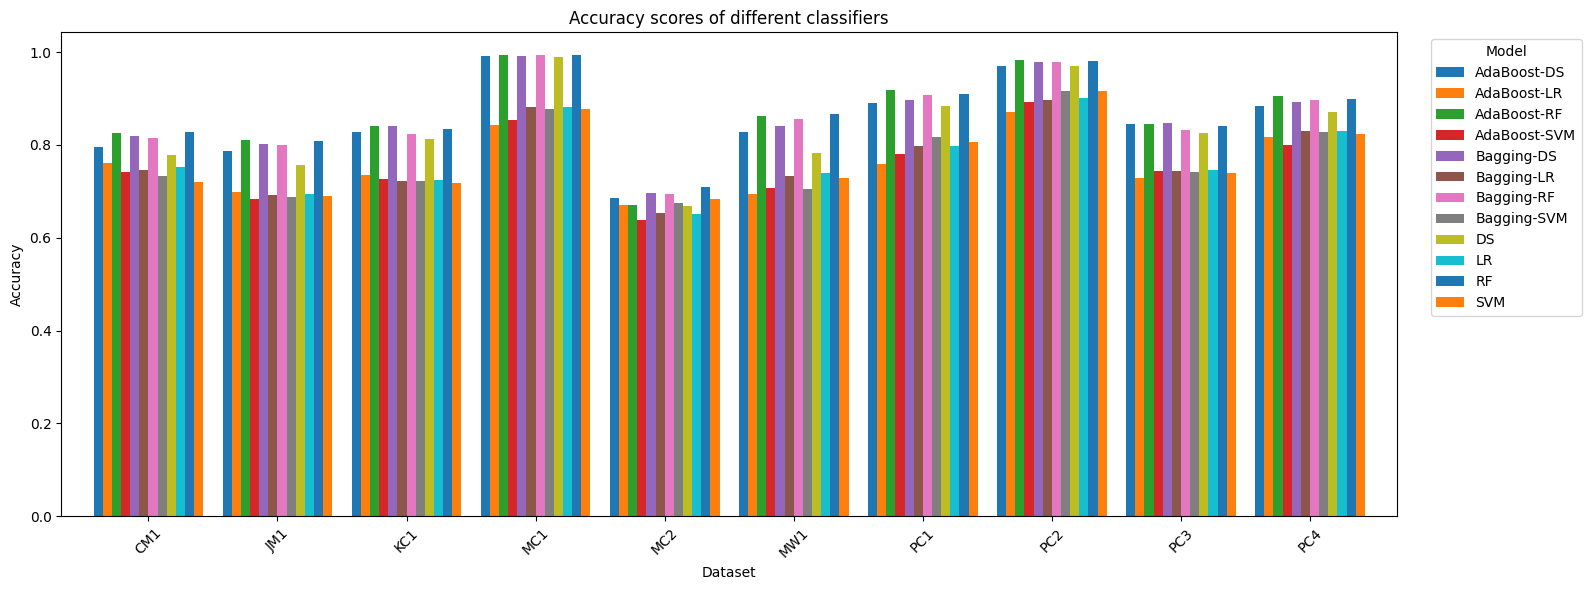

In [17]:
def plot_metric_by_model(results_df, metric, title=None):
    pivot = results_df.pivot_table(index='Dataset', columns='Model', values=metric, aggfunc='mean')
    ax = pivot.plot(kind='bar', figsize=(16, 6), width=0.85)
    ax.set_title(title or metric)
    ax.set_xlabel('Dataset')
    ax.set_ylabel(metric)
    ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_metric_by_model(results_df, 'Accuracy', 'Accuracy scores of different classifiers')

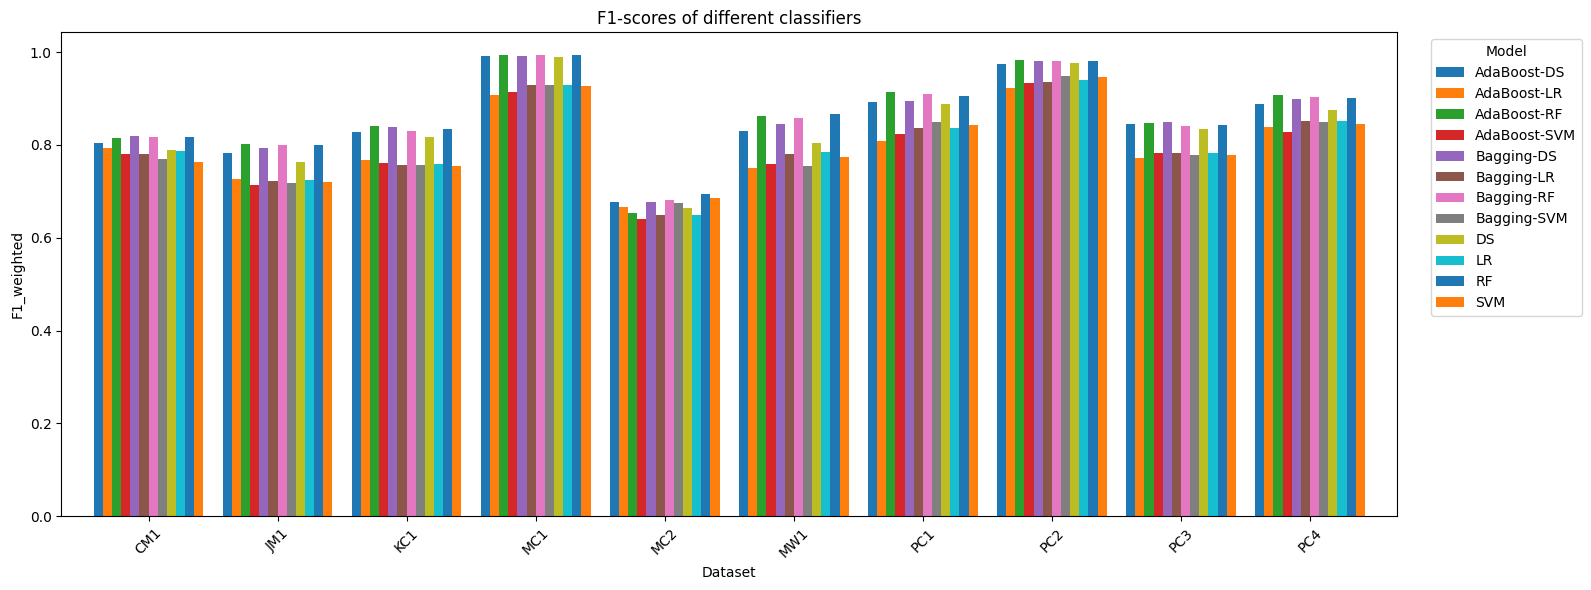

In [18]:
plot_metric_by_model(results_df, 'F1_weighted', 'F1-scores of different classifiers')

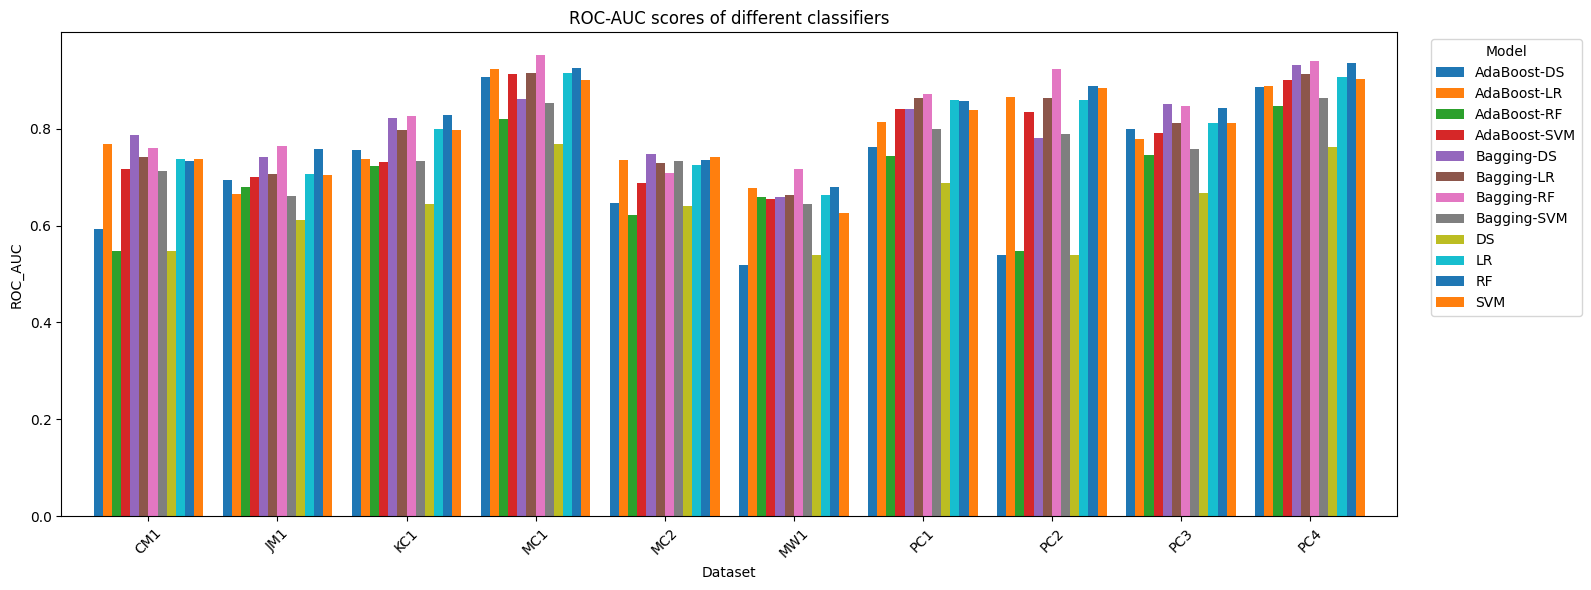

In [19]:
plot_metric_by_model(results_df, 'ROC_AUC', 'ROC-AUC scores of different classifiers')

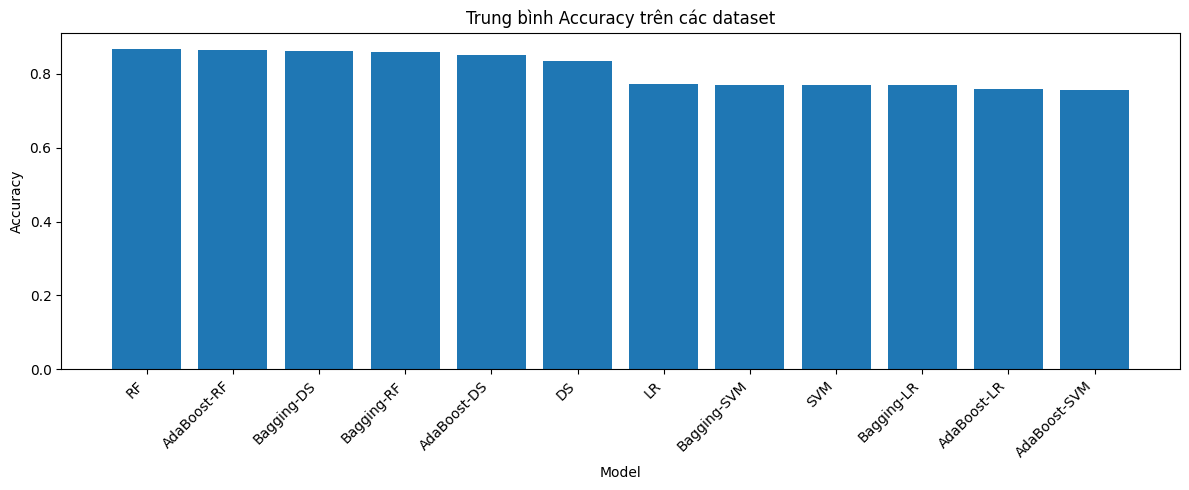

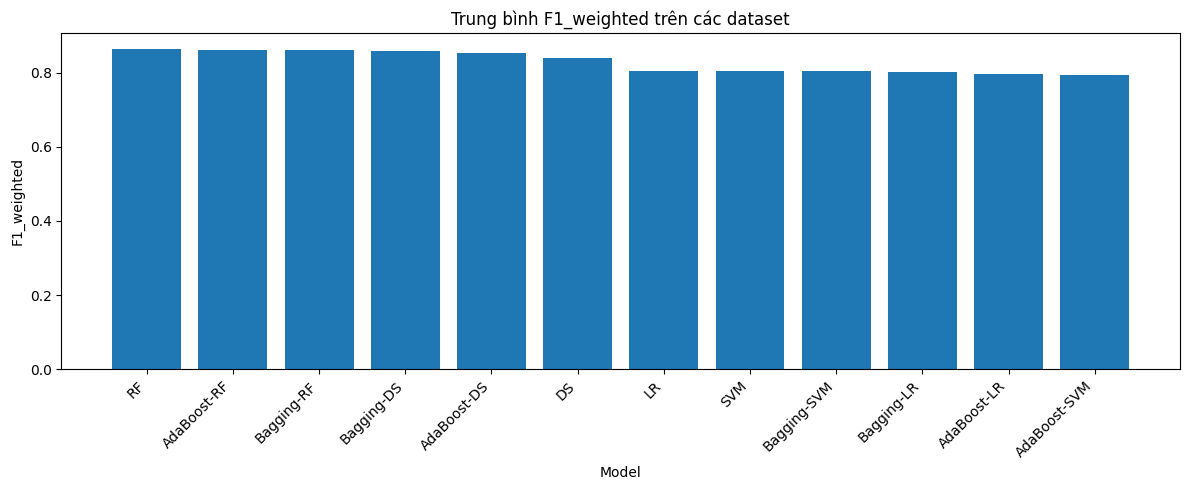

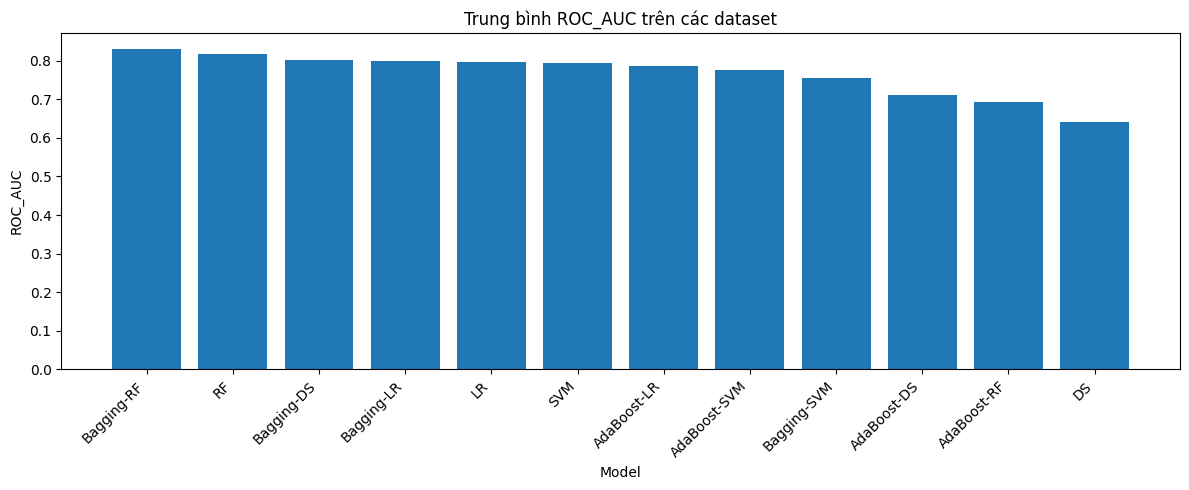

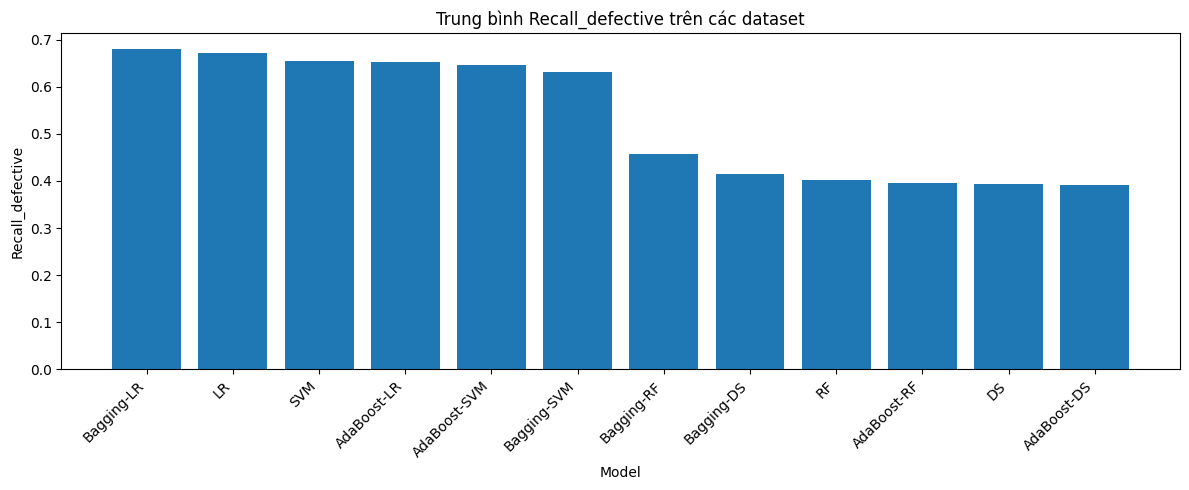

In [20]:
# Biểu đồ trung bình theo mô hình
for metric in ['Accuracy', 'F1_weighted', 'ROC_AUC', 'Recall_defective']:
    avg = model_avg.sort_values(metric, ascending=False)
    plt.figure(figsize=(12, 5))
    plt.bar(avg['Model'], avg[metric])
    plt.title(f'Trung bình {metric} trên các dataset')
    plt.xlabel('Model')
    plt.ylabel(metric)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()